In [1]:
import json
METRICS = ['train_hard_loss', 'train_soft_loss', 'train_acc','test_loss', 'test_acc']
def get_metrics(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return tuple(data[metric] for metric in METRICS)

def populate_dict(path):
    return dict(zip(METRICS, get_metrics(path)))

In [2]:
import numpy as np
STDS = [f'{n:.2f}' for n in np.arange(0, 3, 0.333)]
TARGETS = ['both', 'student', 'teacher']
RUNS = 9

things = {}
for target in TARGETS:
    things[target] = {}
    for std in STDS:
        things[target][std] = {}
        for run in range(RUNS):
            path = f"noise-injection-experiments/{target}/std{std}/{run}/metrics.json"
            things[target][std][run] = populate_dict(path)


In [10]:
def stack_arrays(d, metric):
    arrays = [np.array(d[run][metric]) for run in range(RUNS)]
    stacked = np.stack(arrays)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0, ddof=1)

thing_p = {}
for target in TARGETS:
    thing_p[target] = {}
    for std in STDS:
        thing_p[target][std] = {}
        for metric in METRICS:
            mean, stdd = stack_arrays(things[target][std], metric)
            thing_p[target][std] = {'mean': mean, 'std': stdd}
    
thing_pp = {}
for target in TARGETS:
    thing_pp[target] = {}
    thing_pp[target]['std'] = [std for std in STDS]
    thing_pp[target]['max'] = [thing_p[target][std]['mean'].max() for std in STDS]
    thing_pp[target]['max_std'] = [thing_p[target][std]['std'][-1] for std in STDS]
        

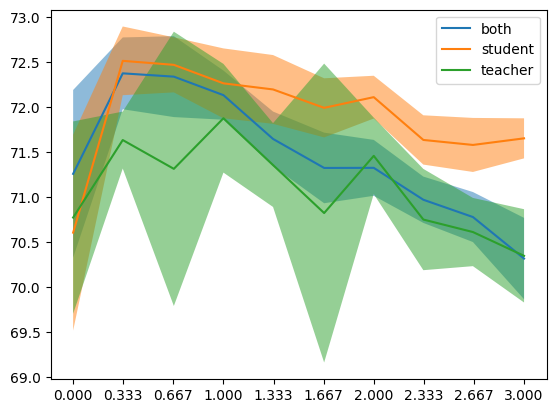

In [11]:
import matplotlib.pyplot as plt
for target in TARGETS:
    x   = np.asarray(thing_pp[target]['std'], dtype=float)      # cast to float
    y   = np.asarray(thing_pp[target]['max'], dtype=float)
    err = np.asarray(thing_pp[target]['max_std'], dtype=float)

    plt.plot(x, y, label=target)
    plt.fill_between(x, y-err, y+err, alpha=0.5)   # element-wise OK now
    plt.xticks(np.arange(0,3.333333,0.33333333))

plt.legend()
plt.show()

In [13]:
def stack_arrays(d, metric):
    arrays = [np.array(d[run][metric]) for run in range(RUNS)]
    stacked = np.stack(arrays)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0, ddof=1)

thing_p = {}
for target in TARGETS:
    thing_p[target] = {}
    for std in STDS:
        thing_p[target][std] = {}
        for metric in ['train_acc', 'test_acc']:
            temp = []
            for run in range(RUNS):
                max_acc = np.array(things[target][std][run][metric]).max()
                temp.append(max_acc)

            temp = np.array(temp)
            thing_p[target][std][metric] = {'mean': temp.mean(), 'std': temp.std()} 

from rich import print as pprint
# pprint(thing_p)



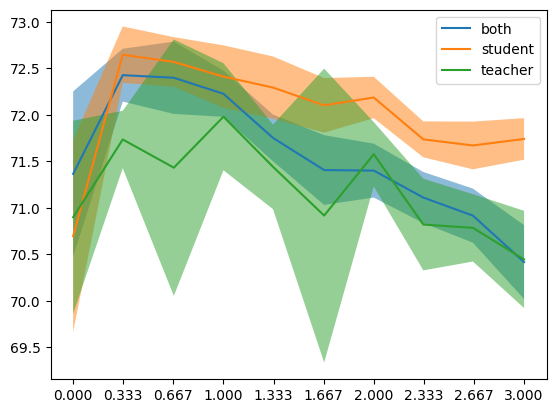

In [14]:
import matplotlib.pyplot as plt
for target in TARGETS:
    x   = np.asarray([std for std in STDS], dtype=float)      # cast to float
    y   = np.asarray([thing_p[target][std]['test_acc']['mean'] for std in STDS], dtype=float)
    err = np.asarray([thing_p[target][std]['test_acc']['std'] for std in STDS], dtype=float)


    plt.plot(x, y, label=target)
    plt.fill_between(x, y-err, y+err, alpha=0.5)   # element-wise OK now
    plt.xticks(np.arange(0,3.333333,0.33333333))

plt.legend()
plt.show()

In [1]:
import torch
def thing():
    for i in range(10000):
        if i % 1000 == 0:
            print(i)
        noise = torch.normal(mean=0.0, std=0.0, size=[128,64,8,8], device='cuda')
        noise_max= noise.max()
        if noise_max > 0:
            print("WEEWOO")
            return
    print("NOPE")
thing()

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
NOPE
